# **Classification Ahmedabad SR(Superresolved)**

In [1]:
!pip install spectral numpy scikit-learn matplotlib torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.0/249.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 63.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [2]:
import numpy as np
from spectral.io import envi
import matplotlib.pyplot as plt

def inspect_hdr_file(hdr_path):
    """Inspect ENVI header file contents"""
    with open(hdr_path, 'r') as f:
        header = f.read()

    print("=== Header File Contents ===")
    print(header[:1000])  # Print first 1000 characters
    print("\nKey Properties:")

    # Parse important metadata
    lines = header.split('\n')
    properties = {
        'samples': next((l.split('=')[1].strip() for l in lines if 'samples' in l), 'N/A'),
        'lines': next((l.split('=')[1].strip() for l in lines if 'lines' in l), 'N/A'),
        'bands': next((l.split('=')[1].strip() for l in lines if 'bands' in l), 'N/A'),
        'data_type': next((l.split('=')[1].strip() for l in lines if 'data type' in l), 'N/A'),
        'byte_order': next((l.split('=')[1].strip() for l in lines if 'byte order' in l), 'N/A'),
        'classes': next((l.split('=')[1].strip() for l in lines if 'classes' in l), 'N/A'),
        'class_names': next((l.split('=')[1].strip() for l in lines if 'class names' in l), 'N/A')
    }

    for k, v in properties.items():
        print(f"{k.upper():<12}: {v}")

# Example usage
hdr_path = '/kaggle/input/ahmedabad-large-area-data/AHM-SR-SUB.HDR'
inspect_hdr_file(hdr_path)

=== Header File Contents ===
ENVI
description = {
  File Resize Result, x resize factor: 1.000000, y resize factor: 1.000000.
  [Thu Jul 24 09:48:01 2025]}
samples = 1838
lines   = 1702
bands   = 194
header offset = 0
file type = ENVI Standard
data type = 4
interleave = bip
sensor type = Unknown
byte order = 0
x start = 1194
y start = 544
map info = {UTM, 1.000, 1.000, 243452.156, 2555762.500, 1.0000000000e+001, 1.0000000000e+001, 43, North, WGS-84, units=Meters}
coordinate system string = {PROJCS["UTM_Zone_43N",GEOGCS["GCS_WGS_1984",DATUM["D_WGS_1984",SPHEROID["WGS_1984",6378137.0,298.257223563]],PRIMEM["Greenwich",0.0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["False_Easting",500000.0],PARAMETER["False_Northing",0.0],PARAMETER["Central_Meridian",75.0],PARAMETER["Scale_Factor",0.9996],PARAMETER["Latitude_Of_Origin",0.0],UNIT["Meter",1.0]]}
wavelength units = Nanometers
band names = {
 Resize (ROI Mask (Band 2:SR_10M_HSI_A.tif):AHM-SR-sub), 
 Resize


=== Data File Properties ===
Shape (lines, samples, bands): (1702, 1838, 194)
Data type: <f4

Band Statistics (first 5 bands):
Band 1: Min=0.00, Max=0.60, Mean=0.07, NaN%=0.0%
Band 2: Min=0.00, Max=0.65, Mean=0.07, NaN%=0.0%
Band 3: Min=0.01, Max=0.67, Mean=0.07, NaN%=0.0%
Band 4: Min=0.02, Max=0.68, Mean=0.07, NaN%=0.0%
Band 5: Min=0.02, Max=0.71, Mean=0.08, NaN%=0.0%


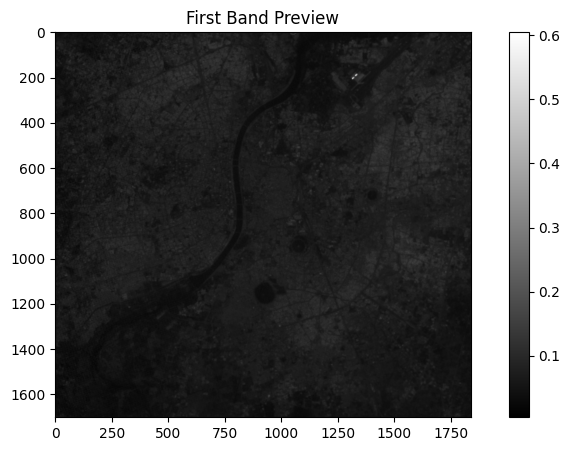

In [3]:
def inspect_dat_file(hdr_path, dat_path):
    """Inspect ENVI data file properties"""
    try:
        # Load the dataset
        dataset = envi.open(hdr_path, dat_path)
        print("\n=== Data File Properties ===")
        print(f"Shape (lines, samples, bands): {dataset.shape}")
        print(f"Data type: {dataset.dtype}")

        # Show band statistics
        print("\nBand Statistics (first 5 bands):")
        for b in range(min(5, dataset.nbands)):
            band = dataset.read_band(b)
            print(f"Band {b+1}: Min={np.nanmin(band):.2f}, Max={np.nanmax(band):.2f}, "
                  f"Mean={np.nanmean(band):.2f}, NaN%={np.isnan(band).mean()*100:.1f}%")

        # Visualize first band
        plt.figure(figsize=(10,5))
        plt.imshow(dataset.read_band(0), cmap='gray')
        plt.title('First Band Preview')
        plt.colorbar()
        plt.show()

        return dataset
    except Exception as e:
        print(f"\nError loading data file: {str(e)}")
        return None

# Example usage
dat_path = '/kaggle/input/ahmedabad-large-area-data/AHM-SR-SUB.dat'
dataset = inspect_dat_file(hdr_path, dat_path)

In [4]:
import numpy as np
from spectral.io import envi
import matplotlib.pyplot as plt

# Load PRISMA data
prisma = envi.open('/kaggle/input/ahmedabad-large-area-data/AHM-SR-SUB.HDR', '/kaggle/input/ahmedabad-large-area-data/AHM-SR-SUB.dat')
data = prisma.load()
print(f"Data shape: {data.shape} (height, width, bands)")

# Load ground truth
gt = envi.open('/kaggle/input/ahmedabad-large-area-data/SRES_CLASS_ROI.HDR', '/kaggle/input/ahmedabad-large-area-data/SRES_CLASS_ROI.dat').read_band(0)
print(f"Ground truth shape: {gt.shape}")

Data shape: (1702, 1838, 194) (height, width, bands)
Ground truth shape: (1702, 1838)


Valid classes: [ 0  1  2  3  4  5  6  7  8  9 10] (Total: 11)


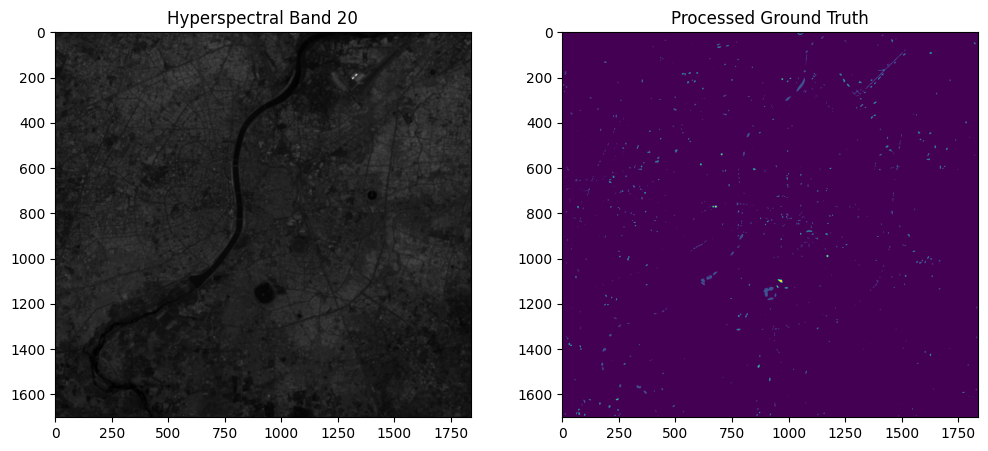

In [5]:
# Convert labels to 0-indexed (background=-1)
valid_mask = gt != 0
gt_processed = np.where(valid_mask, gt - 1, -1)  # Classes: 0 to N-1, background=-1

# Verify classes
unique_classes = np.unique(gt_processed[valid_mask])
num_classes = len(unique_classes)
print(f"Valid classes: {unique_classes} (Total: {num_classes})")

# Visualize
plt.figure(figsize=(12,5))
plt.subplot(121)
plt.imshow(data[:,:,20], cmap='gray')
plt.title('Hyperspectral Band 20')
plt.subplot(122)
plt.imshow(gt_processed, vmin=-1, vmax=num_classes-1)
plt.title('Processed Ground Truth')
plt.show()

In [6]:
import numpy as np

# Create a writable copy upfront
data_np = np.array(data, copy=True)  # Force a writable copy

# Band-wise normalization
for b in range(data_np.shape[2]):
    band = data_np[:, :, b]
    valid_pixels = band[valid_mask]

    if len(valid_pixels) > 0:
        # Normalize only valid pixels
        normalized_band = (band - np.mean(valid_pixels)) / (np.std(valid_pixels) + 1e-6)
        data_np[:, :, b] = normalized_band  # Now this will work

# Replace NaNs
data_np = np.nan_to_num(data_np, nan=0.0)

# keep the original spectral image format:
if hasattr(data, '__class__') and 'Spectral' in str(data.__class__):
    data[:] = data_np  # Try to copy back if possible
else:
    data = data_np

In [7]:
# For a few sample bands
for b in [0, 
          10, 30]:  # Sample band indices
    band = data[:, :, b]
    valid_pixels = band[valid_mask]
    print(f"Band {b}: Mean = {np.mean(valid_pixels):.4f}, Std = {np.std(valid_pixels):.4f}")

Band 0: Mean = 0.0000, Std = 1.0000
Band 10: Mean = -0.0000, Std = 1.0000
Band 30: Mean = -0.0000, Std = 1.0000


In [8]:

from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader

# Prepare labeled pixels
X = data_np[valid_mask]  # (n_pixels, n_bands)
y = gt_processed[valid_mask]  # (n_pixels,)

# Split data (stratified by class)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Verify shapes
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (12328, 194), Test: (5284, 194)


In [9]:
class HSI_Dataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create dataloaders
train_loader = DataLoader(HSI_Dataset(X_train, y_train), batch_size=128, shuffle=True)
test_loader = DataLoader(HSI_Dataset(X_test, y_test), batch_size=256)

In [10]:
import torch
import torch.nn as nn

class Spectral3DCNN(nn.Module):
    def __init__(self, n_bands, n_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv3d(1, 32, kernel_size=(3,1,1), padding=(1,0,0)),
            nn.ReLU(),
            nn.MaxPool3d(kernel_size=(2,1,1)),
            nn.Conv3d(32, 64, kernel_size=(3,1,1), padding=(1,0,0)),
            nn.ReLU(),
            nn.MaxPool3d(kernel_size=(2,1,1)),
            nn.Flatten()
        )

        # Calculate flattened dim for the classifier
        dummy = torch.randn(1, 1, n_bands, 1, 1)  # (batch, channels, depth, height, width)
        flat_dim = self.features(dummy).shape[-1]

        self.classifier = nn.Sequential(
            nn.Linear(flat_dim, 128),
            nn.ReLU(),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        # Assume x shape: (batch, n_bands)
        x = x.unsqueeze(1).unsqueeze(-1).unsqueeze(-1)  # (batch, 1, n_bands, 1, 1)
        x = self.features(x)
        return self.classifier(x)

# Usage:
model = Spectral3DCNN(n_bands=data_np.shape[2], n_classes=num_classes)
print(model)


Spectral3DCNN(
  (features): Sequential(
    (0): Conv3d(1, 32, kernel_size=(3, 1, 1), stride=(1, 1, 1), padding=(1, 0, 0))
    (1): ReLU()
    (2): MaxPool3d(kernel_size=(2, 1, 1), stride=(2, 1, 1), padding=0, dilation=1, ceil_mode=False)
    (3): Conv3d(32, 64, kernel_size=(3, 1, 1), stride=(1, 1, 1), padding=(1, 0, 0))
    (4): ReLU()
    (5): MaxPool3d(kernel_size=(2, 1, 1), stride=(2, 1, 1), padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
  )
  (classifier): Sequential(
    (0): Linear(in_features=3072, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=11, bias=True)
  )
)


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score

# Initialize device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 1. Define model, loss function and optimizer
model = Spectral3DCNN(n_bands=data_np.shape[2], n_classes=num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 2. Enhanced training function with accuracy tracking
def train_with_metrics(model, loader, criterion, optimizer, epochs=100):
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        for batch_idx, (X_batch, y_batch) in enumerate(loader):
            # Verify inputs
            assert not torch.isnan(X_batch).any(), f"NaN in batch {batch_idx}"
            assert y_batch.min() >= 0, f"Invalid label {y_batch.min()}"

            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            # Forward pass
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            # Calculate accuracy
            _, predicted = torch.max(outputs.data, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(loader)
        epoch_acc = 100 * correct / total

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Loss: {epoch_loss:.4f} | "
              f"Accuracy: {epoch_acc:.2f}%")

# 3. Execute training
train_with_metrics(
    model=model,
    loader=train_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=100
)

Using device: cuda
Epoch 1/100 | Loss: 0.3908 | Accuracy: 87.31%
Epoch 2/100 | Loss: 0.0800 | Accuracy: 97.01%
Epoch 3/100 | Loss: 0.0726 | Accuracy: 97.26%
Epoch 4/100 | Loss: 0.0624 | Accuracy: 97.69%
Epoch 5/100 | Loss: 0.0558 | Accuracy: 97.97%
Epoch 6/100 | Loss: 0.0512 | Accuracy: 97.93%
Epoch 7/100 | Loss: 0.0544 | Accuracy: 98.00%
Epoch 8/100 | Loss: 0.0494 | Accuracy: 98.23%
Epoch 9/100 | Loss: 0.0441 | Accuracy: 98.39%
Epoch 10/100 | Loss: 0.0444 | Accuracy: 98.33%
Epoch 11/100 | Loss: 0.0432 | Accuracy: 98.43%
Epoch 12/100 | Loss: 0.0414 | Accuracy: 98.43%
Epoch 13/100 | Loss: 0.0344 | Accuracy: 98.75%
Epoch 14/100 | Loss: 0.0372 | Accuracy: 98.57%
Epoch 15/100 | Loss: 0.0328 | Accuracy: 98.81%
Epoch 16/100 | Loss: 0.0344 | Accuracy: 98.82%
Epoch 17/100 | Loss: 0.0385 | Accuracy: 98.64%
Epoch 18/100 | Loss: 0.0255 | Accuracy: 99.16%
Epoch 19/100 | Loss: 0.0258 | Accuracy: 99.14%
Epoch 20/100 | Loss: 0.0239 | Accuracy: 99.21%
Epoch 21/100 | Loss: 0.0220 | Accuracy: 99.24%
Epo


Model Evaluation Report
----------------------------------------
Overall Accuracy (OA): 0.9989 (99.89%)
Kappa Coefficient (κ): 0.9987
----------------------------------------
Per-Class Metrics:
  Class 0:
    Producer's Accuracy (Recall): 1.0000
    User's Accuracy (Precision):  1.0000
  Class 1:
    Producer's Accuracy (Recall): 0.9971
    User's Accuracy (Precision):  1.0000
  Class 2:
    Producer's Accuracy (Recall): 1.0000
    User's Accuracy (Precision):  1.0000
  Class 3:
    Producer's Accuracy (Recall): 1.0000
    User's Accuracy (Precision):  1.0000
  Class 4:
    Producer's Accuracy (Recall): 1.0000
    User's Accuracy (Precision):  1.0000
  Class 5:
    Producer's Accuracy (Recall): 0.9985
    User's Accuracy (Precision):  0.9985
  Class 6:
    Producer's Accuracy (Recall): 0.9852
    User's Accuracy (Precision):  0.9950
  Class 7:
    Producer's Accuracy (Recall): 1.0000
    User's Accuracy (Precision):  0.9956
  Class 8:
    Producer's Accuracy (Recall): 1.0000
    User'

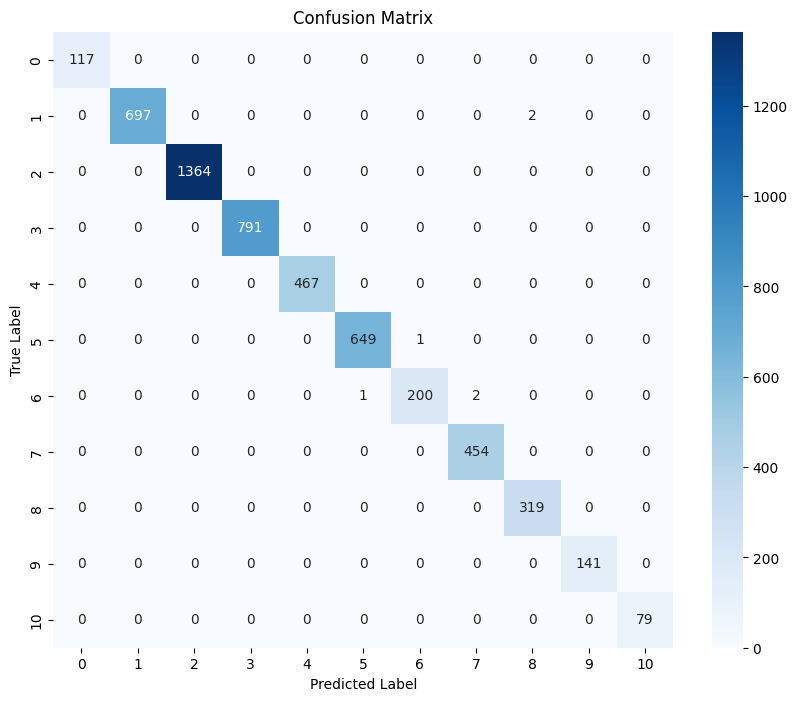

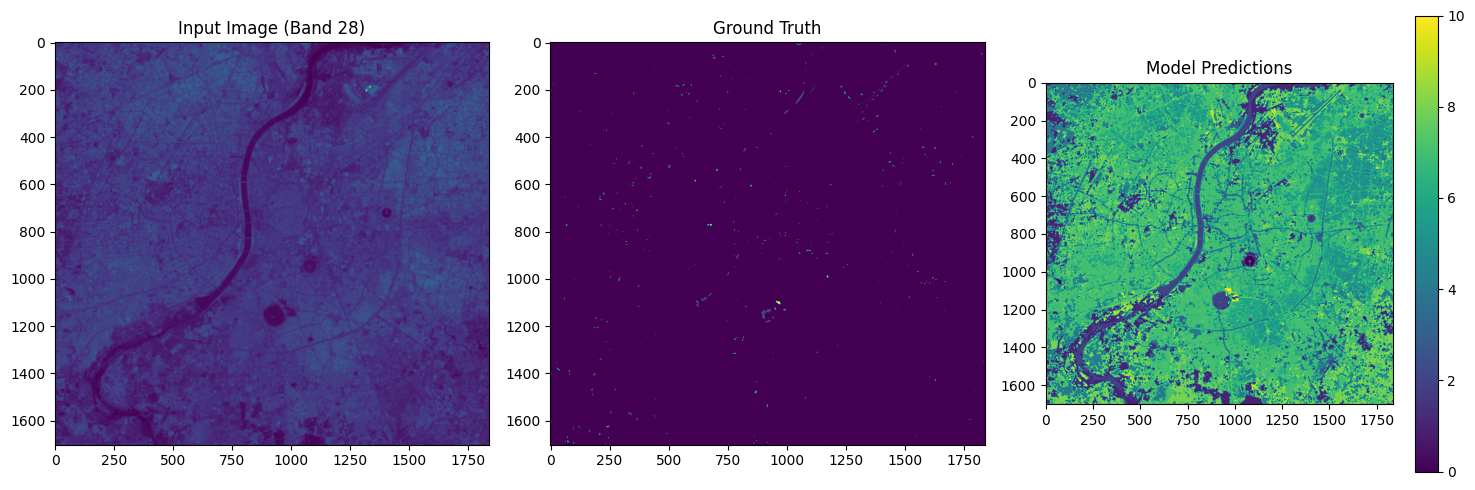

Model saved to prisma_model.pth


In [12]:
# 4. Evaluate the model on test set

import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, cohen_kappa_score, classification_report


def evaluate_model(model, test_loader):
    """
    Evaluates the model and prints a detailed report including OA, Kappa,
    Producer's Accuracy, and User's Accuracy.
    """
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    # --- Metrics Calculation ---
    cm = confusion_matrix(all_labels, all_preds)
    
    # 1. Overall Accuracy (OA)
    overall_acc = np.trace(cm) / np.sum(cm)

    # 2. Kappa Coefficient (κ)
    kappa = cohen_kappa_score(all_labels, all_preds)

    # 3. Producer's and User's Accuracy
    true_positives = np.diag(cm)
    
    # Producer's Accuracy (Recall): TP / (sum of the actual class row)
    producers_accuracy = true_positives / np.sum(cm, axis=1)
    producers_accuracy = np.nan_to_num(producers_accuracy) # Handle division by zero
    
    # User's Accuracy (Precision): TP / (sum of the predicted class column)
    users_accuracy = true_positives / np.sum(cm, axis=0)
    users_accuracy = np.nan_to_num(users_accuracy) # Handle division by zero

    # --- Display Results ---
    print("\nModel Evaluation Report")
    print("-" * 40)
    print(f"Overall Accuracy (OA): {overall_acc:.4f} ({overall_acc:.2%})")
    print(f"Kappa Coefficient (κ): {kappa:.4f}")
    print("-" * 40)

    print("Per-Class Metrics:")
    # Assuming you have a list of class names, otherwise use class indices
    # class_names = ['Class 0', 'Class 1', ...] 
    for i in range(len(producers_accuracy)):
        print(f"  Class {i}:")
        print(f"    Producer's Accuracy (Recall): {producers_accuracy[i]:.4f}")
        print(f"    User's Accuracy (Precision):  {users_accuracy[i]:.4f}")
    
    print("\nFull Classification Report (scikit-learn):")
    print(classification_report(all_labels, all_preds))

    # Confusion Matrix Plot
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
    
# Run evaluation
evaluate_model(model, test_loader)

# 5. Visualize predictions on full image
def predict_full_image(model, data, gt=None):
    model.eval()
    h, w, c = data.shape
    pred_map = np.zeros((h, w), dtype=np.uint8)

    # Predict in batches to save memory
    batch_size = 4096
    with torch.no_grad():
        for i in range(0, h * w, batch_size):
            batch = data.reshape(-1, c)[i:i+batch_size]
            batch_tensor = torch.FloatTensor(batch).to(device)
            outputs = model(batch_tensor)
            _, predicted = torch.max(outputs, 1)
            pred_map.ravel()[i:i+batch_size] = predicted.cpu().numpy()

    # Visualization
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 2 if gt is None else 3, 1)
    plt.imshow(data[:, :, 28], cmap='viridis')  #  To show one band
    plt.title('Input Image (Band 28)')

    if gt is not None:
        plt.subplot(1, 3, 2)
        plt.imshow(gt, vmin=0, vmax=num_classes-1)
        plt.title('Ground Truth')

    plt.subplot(1, 2 if gt is None else 3, 3 if gt is None else 3)
    plt.imshow(pred_map, vmin=0, vmax=num_classes-1)
    plt.title('Model Predictions')
    plt.colorbar()

    plt.tight_layout()
    plt.show()

    return pred_map

# Generate and visualize predictions
full_prediction = predict_full_image(model, data_np, gt_processed)

# 6. Save the trained model
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'num_classes': num_classes,
    'n_bands': data_np.shape[2]
}, 'prisma_model.pth')

print("Model saved to prisma_model.pth")

def train_with_history(model, loader, criterion, optimizer, epochs=20):
    history = {'loss': [], 'accuracy': []}

    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            _, predicted = torch.max(outputs.data, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(loader)
        epoch_acc = 100 * correct / total

        history['loss'].append(epoch_loss)
        history['accuracy'].append(epoch_acc)

        print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")

    return history

# Then plot it :
def plot_history(history):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history['loss'])
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')

    plt.subplot(1, 2, 2)
    plt.plot(history['accuracy'])
    plt.title('Training Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')

    plt.tight_layout()
    plt.show()



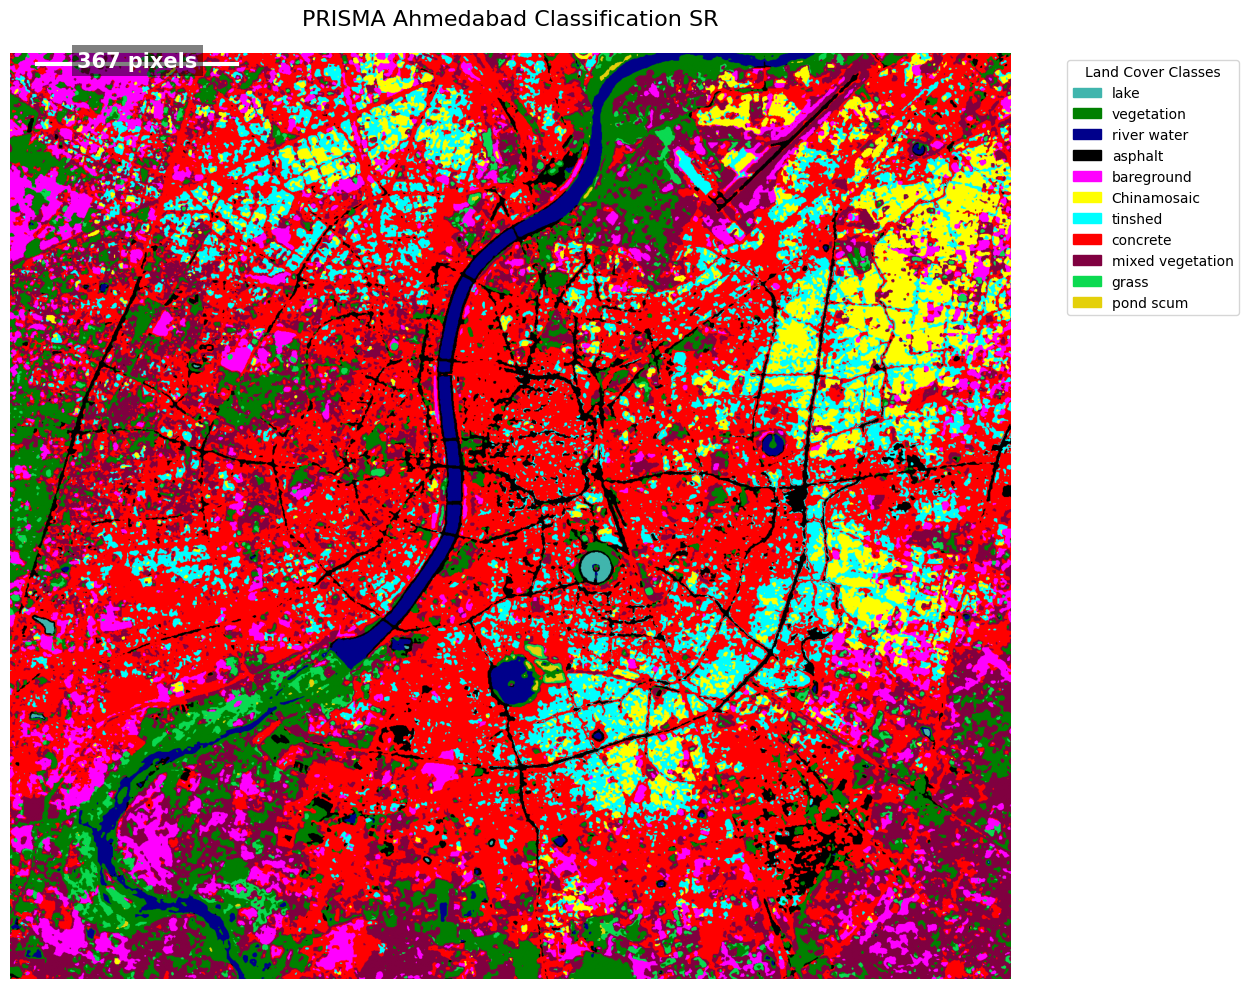

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# 1. Define your custom class names and colors
class_names = {
    0: "lake",
    1: "vegetation",
    2: "river water",
    3: "asphalt",
    4: "bareground",
    5: "Chinamosaic",
    6: "tinshed",
    7: "concrete",
    8: "mixed vegetation",
    9: "grass",
    10: "pond scum",

}

# Hexadecimal color scheme
hex_colors = {
    0: "#40B5AD",
    1: "#008000",
    2: "#00008B",
    3: "#000000",
    4: "#FF00FF",
    5: "#FFFF00",
    6: "#00FFFF",
    7: "#FF0000",
    8: "#800040",
    9: "#0BDA51",
    10: "#E4D00A",
}

# visualization function for hex colors
def visualize_with_hex_colors(pred_map, class_names, hex_colors, title="Classification Results"):
    # Convert hex colors to RGB (0-1 range)
    def hex_to_rgb(hex_color):
        hex_color = hex_color.lstrip('#')
        return np.array([int(hex_color[i:i+2], 16)/255 for i in (0, 2, 4)])

    class_colors = {k: hex_to_rgb(v) for k, v in hex_colors.items()}

    # Create colored prediction map
    h, w = pred_map.shape
    colored_map = np.zeros((h, w, 3))
    for class_id, color in class_colors.items():
        colored_map[pred_map == class_id] = color

    # Plot with legend
    plt.figure(figsize=(15, 10))
    plt.imshow(colored_map)

    # Create legend patches
    patches = [mpatches.Patch(color=hex_colors[k], label=v)
               for k, v in class_names.items()]

    # Add legend
    plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left',
               title="Land Cover Classes", facecolor='white')

    plt.title(title, fontsize=16, pad=20)
    plt.axis('off')

    # Add scale bar
    scale_length = int(w*0.2)  # 20% of image width
    plt.plot([50, 50+scale_length], [20, 20], color='white', linewidth=3)
    plt.text(50+scale_length/2, 25, f'{scale_length} pixels',
             color='white', ha='center', fontsize=15, weight='bold',
             bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))

    plt.tight_layout()
    plt.show()

    # Save the visualization
    plt.imsave('classified_image_hex.png', colored_map)
    return colored_map

# Usage
colored_result = visualize_with_hex_colors(
    full_prediction,
    class_names,
    hex_colors,
    title="PRISMA Ahmedabad Classification SR"
)

# **Save Classified SR**

In [14]:
pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 71.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [15]:
#TO know metadata of file 
import rasterio

with rasterio.open('/kaggle/input/ahmedabad-large-area-data/AHM_SR_SUB_tiff.tif') as src:
    ulx, uly = src.transform * (0, 0)  # Upper left corner coordinates
    pixel_width = src.transform[0]      # Pixel size in x direction (longitude)
    pixel_height = -src.transform[4]    # Pixel size in y direction (latitude), usually negative so take abs
    
    print("Upper Left Longitude:", ulx)
    print("Upper Left Latitude:", uly)
    print("Pixel size (degrees):", pixel_width, "(lon),", pixel_height, "(lat)")


Upper Left Longitude: 243452.156
Upper Left Latitude: 2555762.5
Pixel size (degrees): 10.0 (lon), 10.0 (lat)


In [16]:

import rasterio
from rasterio.transform import Affine
import numpy as np

def save_colored_geotiff(pred_map, class_colors, class_names, output_path,
                        ulx=0, uly=0, pixel_size=1, epsg_code=4326):
    """
    Save colored classification map as GeoTIFF with class names and colors in metadata

    Parameters:
    - pred_map: 2D numpy array with class predictions (integer values)
    - class_colors: Dictionary mapping class values to RGB hex colors
                   Example: {0: "#FF0000", 1: "#00FF00", ...}
    - class_names: Dictionary mapping class values to class names
                   Example: {0: "Urban", 1: "Forest", ...}
    - output_path: Path to save the GeoTIFF
    - ulx, uly: Upper left coordinates (default 0,0)
    - pixel_size: Pixel size in coordinate units (default 1)
    - epsg_code: EPSG code for CRS (default: 4326 for WGS84)
    """
    # Convert hex colors to RGB (0-255 range)
    def hex_to_rgb(hex_color):
        hex_color = hex_color.lstrip('#')
        return [int(hex_color[i:i+2], 16) for i in (0, 2, 4)]

    # Create RGB array
    height, width = pred_map.shape
    rgb_array = np.zeros((height, width, 3), dtype=np.uint8)

    for class_id, hex_color in class_colors.items():
        mask = (pred_map == class_id)
        rgb_array[mask] = hex_to_rgb(hex_color)

    # Reorder to (bands, height, width)
    rgb_array = np.moveaxis(rgb_array, -1, 0)

    # Create transform
    transform = Affine.translation(ulx, uly) * Affine.scale(pixel_size, -pixel_size)

    # Prepare class metadata
    class_metadata = {}
    for class_id, name in class_names.items():
        class_metadata[f'CLASS_{class_id}_NAME'] = name
    for class_id, hex_color in class_colors.items():
         class_metadata[f'CLASS_{class_id}_COLOR'] = hex_color


    # Create profile
    profile = {
        'driver': 'GTiff',
        'height': height,
        'width': width,
        'count': 3,
        'dtype': 'uint8',
        'crs': rasterio.crs.CRS.from_epsg(epsg_code),
        'transform': transform,
        'photometric': 'RGB',
        'nodata': None,
    }

    # Save the RGB GeoTIFF with metadata
    with rasterio.open(output_path, 'w', **profile) as dst:
        dst.write(rgb_array)
        # Store class names and colors as dataset-level tags
        dst.update_tags(**class_metadata)


    print(f"Saved colored classification map to {output_path} with class names and colors in metadata")

class_names = {
    0: "lake",
    1: "vegetation",
    2: "river water",
    3: "asphalt",
    4: "bareground",
    5: "Chinamosaic",
    6: "tinshed",
    7: "concrete",
    8: "mixed vegetation",
    9: "grass",
    10: "pond scum",

}

# Hexadecimal color scheme
hex_colors = {
    0: "#40B5AD",
    1: "#008000",
    2: "#00008B",
    3: "#000000",
    4: "#FF00FF",
    5: "#FFFF00",
    6: "#00FFFF",
    7: "#FF0000",
    8: "#800040",
    9: "#0BDA51",
    10: "#E4D00A",
}

save_colored_geotiff(
    pred_map=full_prediction,  # Your 2D prediction array
    class_colors=hex_colors,   # Your hex color dictionary
    class_names=class_names,   # Your class names dictionary
    output_path='classification_Ahmedabad_SR.tif',
    ulx=243452.156,       # Replace with your upper left longitude
    uly=2555762.5,       # Replace with your upper left latitude
    pixel_size=10.0 ,  # Replace with your pixel size in degrees
    epsg_code=4326  # WGS84
)

Saved colored classification map to classification_Ahmedabad_SR.tif with class names and colors in metadata
